# Car Price Prediction

This notebook documents the project understanding before the modeling work begins.

The goal is to inspect the dataset, understand the target variable, and identify the main data-quality issues before feature engineering or model training.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = '../data/raw/car_sales.csv'
df = pd.read_csv(path)

df.head()


,brand,model,year,mileage_km,fuel_type,transmission,engine_cc,seats,owner_count,price
0,Toyota,Corolla,2023,11022.0,Petrol,Automatic,1656.0,5,4,971315.10
1,Mahindra,Thar,2018,84740.0,CNG,Automatic,1937.0,4,3,801033.25
2,Maruti,Brezza,2024,82282.0,CNG,Automatic,1163.0,5,3,366299.42
3,Mercedes,C Class,2022,47291.0,CNG,Automatic,1960.0,7,3,776649.63
4,Mercedes,GLC,2020,23731.0,NaN,Automatic,2472.0,5,1,1345190.63


In [2]:
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())


Shape: (600, 10)

Columns:
['brand', 'model', 'year', 'mileage_km', 'fuel_type', 'transmission', 'engine_cc', 'seats', 'owner_count', 'price']

Dtypes:
brand               str
model               str
year              int64
mileage_km      float64
fuel_type           str
transmission        str
engine_cc       float64
seats             int64
owner_count       int64
price           float64
dtype: object

Missing values:
brand            0
model            0
year             0
mileage_km      12
fuel_type       22
transmission    14
engine_cc       17
seats            0
owner_count      0
price            0
dtype: int64


In [3]:
df['price'].describe()


count    6.000000e+02
mean     8.824914e+05
std      1.780858e+05
min      3.662994e+05
25%      7.708216e+05
50%      8.706340e+05
75%      9.995840e+05
max      1.380962e+06
Name: price, dtype: float64

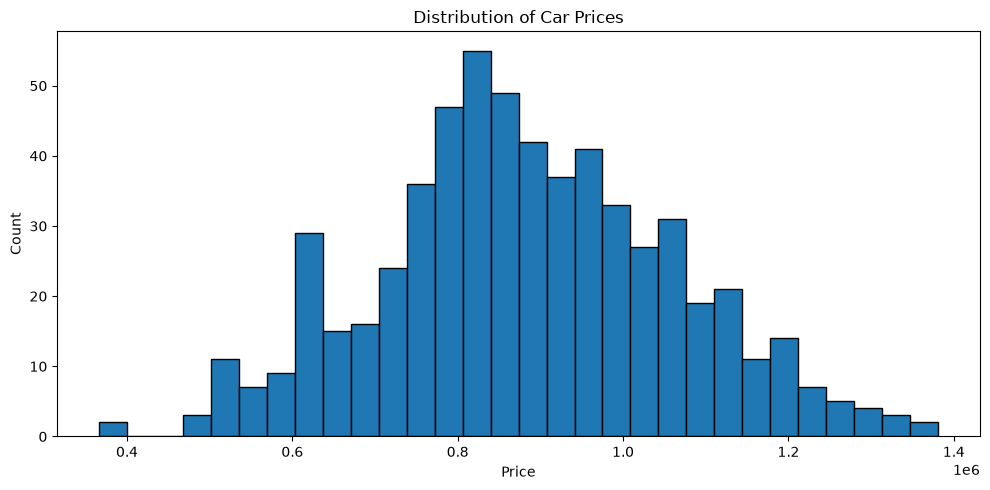

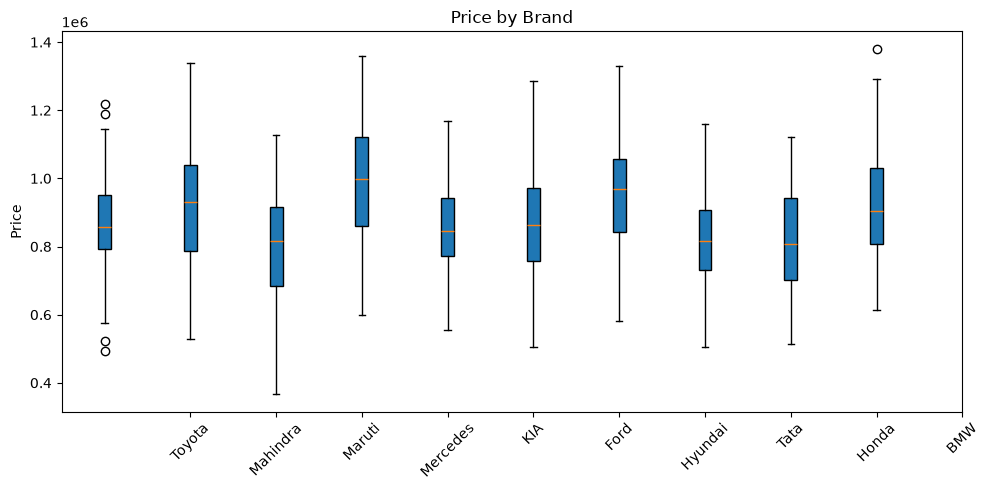

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=30, edgecolor='black')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for brand, group in df.groupby('brand')['price']:
    plt.boxplot(group.values, positions=[list(df['brand'].unique()).index(brand)], patch_artist=True)
plt.xticks(range(1, len(df['brand'].unique()) + 1), df['brand'].unique(), rotation=45)
plt.title('Price by Brand')
plt.ylabel('Price')
plt.tight_layout()
plt.show()
